Loading data from ../data/crypto_with_indicators.parquet...
  Coins after quality filter : 615
  Date range                 : 2021-04-21 → 2026-04-17
  Return matrix shape        : (1823, 615)

[Method 1] Computing copula tail dependence for 615 coins...
  Progress: 0/615
  Progress: 10/615
  Progress: 20/615
  Progress: 30/615
  Progress: 40/615
  Progress: 50/615
  Progress: 60/615
  Progress: 70/615
  Progress: 80/615
  Progress: 90/615
  Progress: 100/615
  Progress: 110/615
  Progress: 120/615
  Progress: 130/615
  Progress: 140/615
  Progress: 150/615
  Progress: 160/615
  Progress: 170/615
  Progress: 180/615
  Progress: 190/615
  Progress: 200/615
  Progress: 210/615
  Progress: 220/615
  Progress: 230/615
  Progress: 240/615
  Progress: 250/615
  Progress: 260/615
  Progress: 270/615
  Progress: 280/615
  Progress: 290/615
  Progress: 300/615
  Progress: 310/615
  Progress: 320/615
  Progress: 330/615
  Progress: 340/615
  Progress: 350/615
  Progress: 360/615
  Progress: 370/

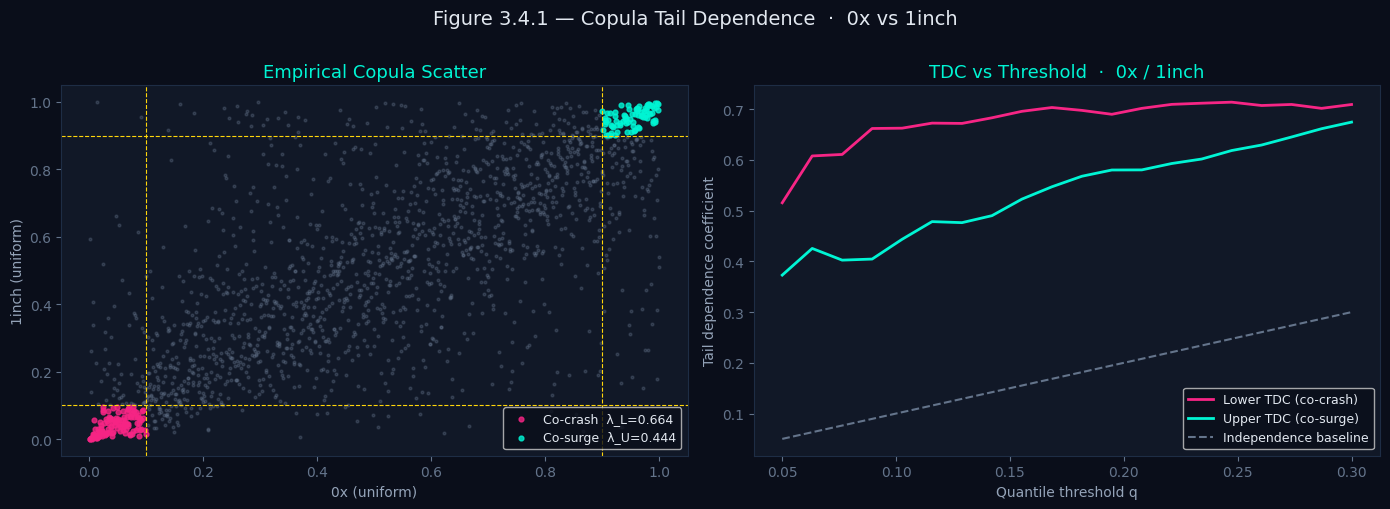

  λ_L (co-crash)  = 0.6637  [independence baseline = 0.1000]
  λ_U (co-surge)  = 0.4443  [independence baseline = 0.1000]
  Excess co-crash = 0.5637  (positive = diversification illusion confirmed)

[Method 2] HMM regime correlation complete.
  Bear (π=0.275)  |  median pairwise corr = nan
  Neutral (π=0.044)  |  median pairwise corr = nan
  Bull (π=0.681)  |  median pairwise corr = nan


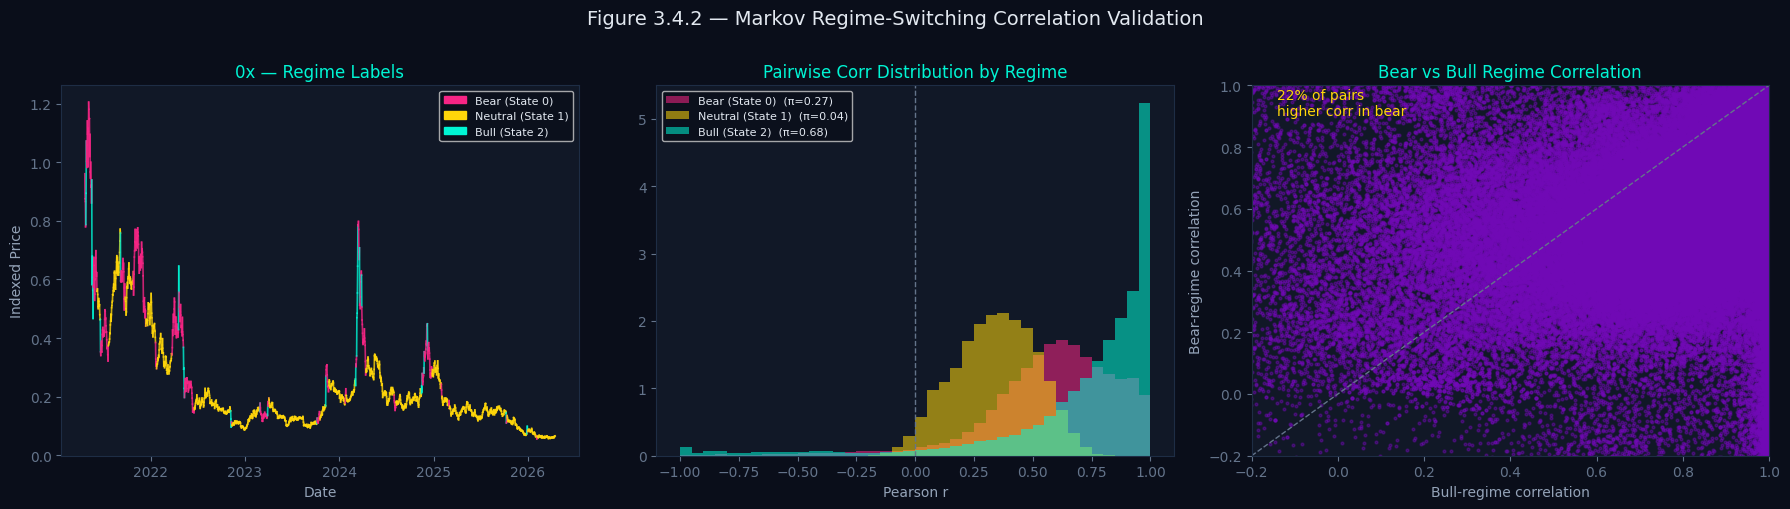


[Method 3] Fitting GraphicalLassoCV (this may take a few minutes)...
  α selected by 5-fold CV : 0.658668
  Non-zero edges in precision graph : 3228  (out of 188805 possible)
  Sparsity : 98.29%


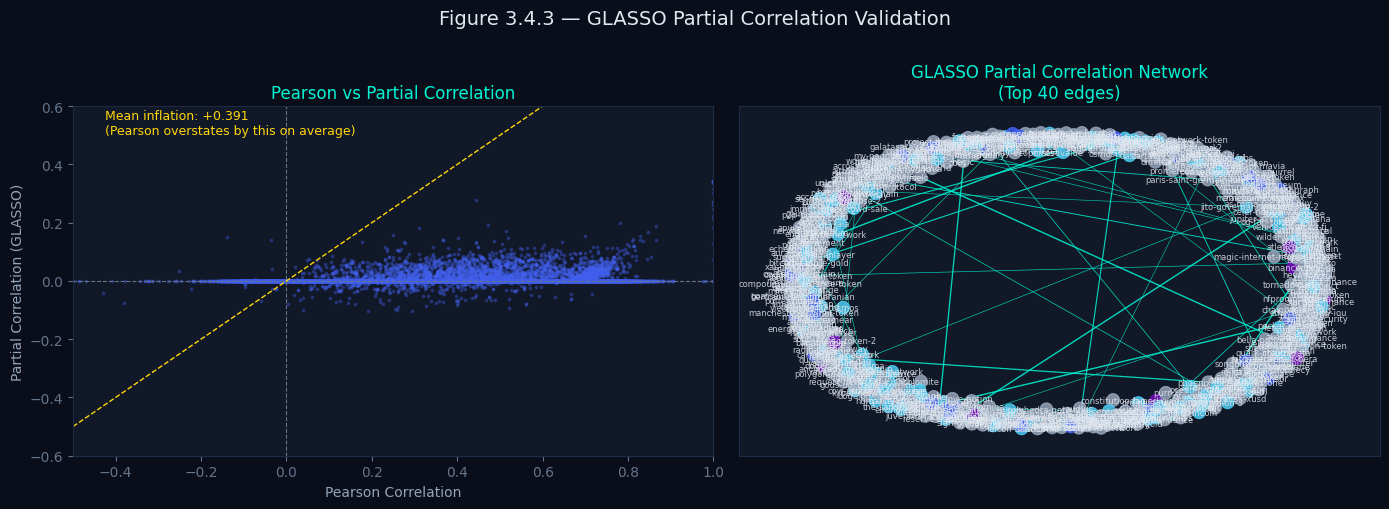

  dtaidistance not found — using scipy DTW (slower). pip install dtaidistance

[Method 4] Computing DTW distances for 615 coins (window=30)...
  Progress: 0/615
  Progress: 10/615
  Progress: 20/615
  Progress: 30/615
  Progress: 40/615
  Progress: 50/615
  Progress: 60/615
  Progress: 70/615
  Progress: 80/615
  Progress: 90/615
  Progress: 100/615
  Progress: 110/615
  Progress: 120/615
  Progress: 130/615
  Progress: 140/615
  Progress: 150/615
  Progress: 160/615
  Progress: 170/615
  Progress: 180/615
  Progress: 190/615
  Progress: 200/615
  Progress: 210/615
  Progress: 220/615
  Progress: 230/615
  Progress: 240/615
  Progress: 250/615
  Progress: 260/615
  Progress: 270/615
  Progress: 280/615
  Progress: 290/615
  Progress: 300/615
  Progress: 310/615
  Progress: 320/615
  Progress: 330/615
  Progress: 340/615
  Progress: 350/615
  Progress: 360/615
  Progress: 370/615
  Progress: 380/615
  Progress: 390/615
  Progress: 400/615
  Progress: 410/615
  Progress: 420/615
  Progre

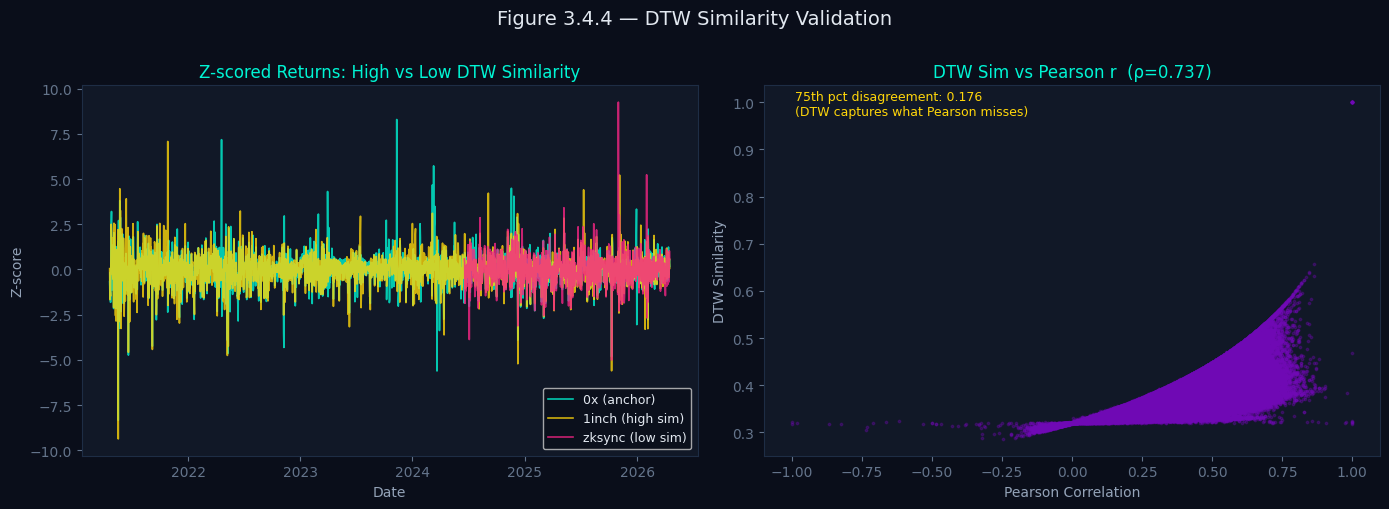


[Method 5] Cointegration testing for 615 coins...
  Testing all 188805 pairs (this takes a while)...
  Progress: 0/615
  Progress: 5/615
  Progress: 10/615
  Progress: 15/615
  Progress: 20/615
  Progress: 25/615
  Progress: 30/615
  Progress: 35/615
  Progress: 40/615
  Progress: 45/615
  Progress: 50/615
  Progress: 55/615
  Progress: 60/615
  Progress: 65/615
  Progress: 70/615
  Progress: 75/615
  Progress: 80/615
  Progress: 85/615
  Progress: 90/615
  Progress: 95/615
  Progress: 100/615
  Progress: 105/615
  Progress: 110/615
  Progress: 115/615
  Progress: 120/615
  Progress: 125/615
  Progress: 130/615
  Progress: 135/615
  Progress: 140/615
  Progress: 145/615
  Progress: 150/615
  Progress: 155/615
  Progress: 160/615
  Progress: 165/615
  Progress: 170/615
  Progress: 175/615
  Progress: 180/615
  Progress: 185/615
  Progress: 190/615
  Progress: 195/615
  Progress: 200/615
  Progress: 205/615
  Progress: 210/615
  Progress: 215/615
  Progress: 220/615
  Progress: 225/615


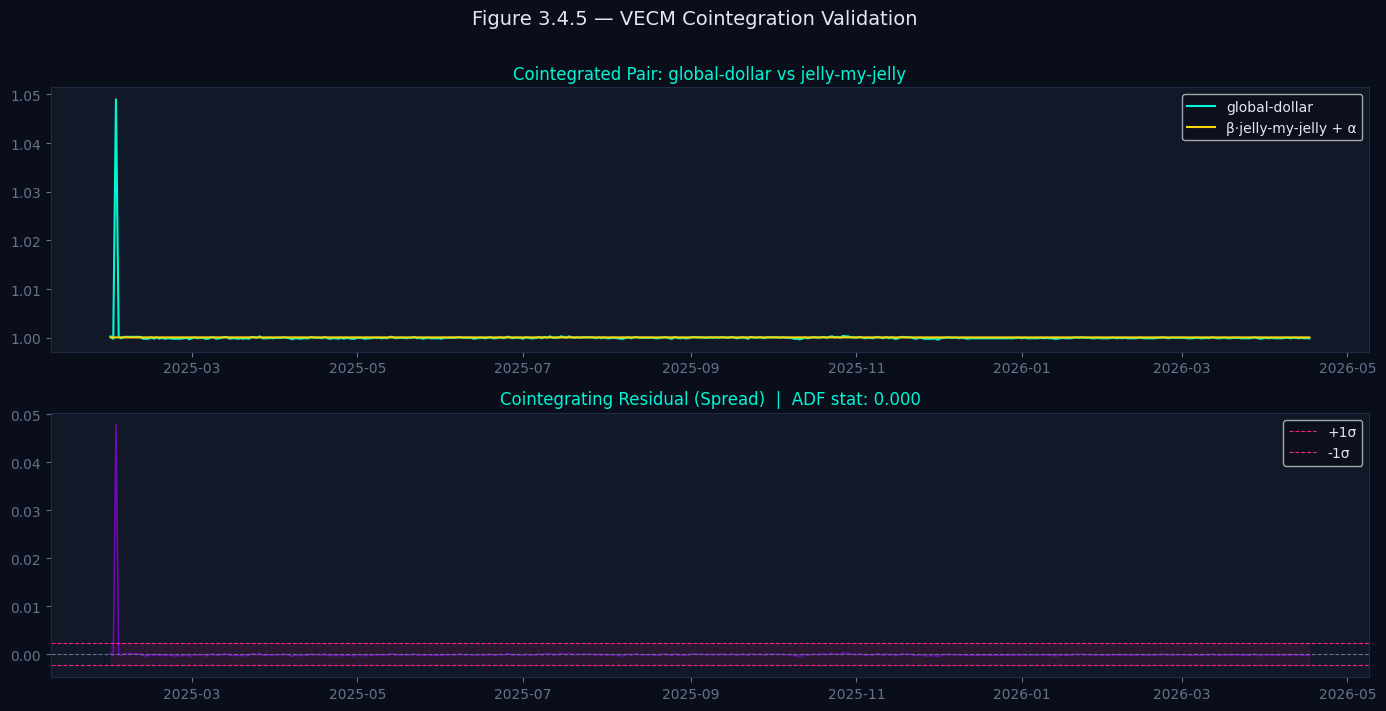


[Rank Aggregation] Composite matrix built from 5 methods.
  Similarity range: [0.000, 0.992]
  Mean pairwise sim: 0.491


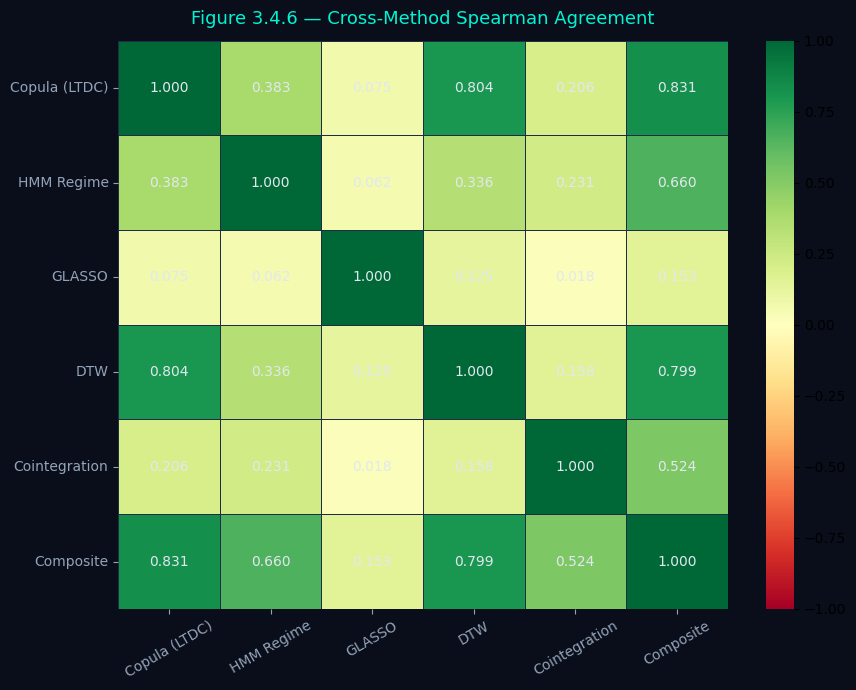


Section 3.4 COMPLETE
All outputs saved to: similarity_outputs/
Files produced:
  coint_pairs_table.csv
  coint_similarity_matrix.csv
  composite_similarity_matrix.csv
  copula_ltdc_matrix.csv
  copula_utdc_matrix.csv
  dtw_similarity_matrix.csv
  fig_341_copula_0x_1inch.png
  fig_341_copula_aave_aerodrome-finance.png
  fig_342_hmm_validation.png
  fig_343_glasso_validation.png
  fig_344_dtw_validation.png
  fig_345_coint_validation.png
  fig_346_method_agreement.png
  glasso_partial_corr_matrix.csv
  glasso_similarity_matrix.csv
  hmm_regime_0_corr.csv
  hmm_regime_1_corr.csv
  hmm_regime_2_corr.csv
  hmm_similarity_matrix.csv

Pass `composite` to section_35_clustering.py as the input matrix.


In [3]:
"""
═══════════════════════════════════════════════════════════════════════════════
SECTION 3.4 — BEHAVIORAL SIMILARITY METHODS
Thesis: Behavioral Similarity Classification of Cryptocurrency Assets

Five methods implemented as self-contained functions.
Each returns a similarity/distance matrix over the coin universe.

INPUT  : crypto_with_indicators.parquet  (or .csv)
         Must have columns: date, coin_id, symbol, close, log_ret (or we compute it)
         Plus indicator columns for regime features.

OUTPUT : Five NxN matrices  +  composite rank-aggregated matrix
         All saved as .npy and .csv  for Section 4 use

USAGE  :
    python section_34_similarity_methods.py
    (or paste cells into a Jupyter notebook — each METHOD block is one cell)

DEPENDENCIES :
    pip install numpy pandas scipy scikit-learn statsmodels hmmlearn dtaidistance
                copulas networkx matplotlib seaborn polars pyarrow
═══════════════════════════════════════════════════════════════════════════════
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import squareform
from sklearn.covariance import GraphicalLassoCV
from sklearn.preprocessing import StandardScaler
import os

# ─────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────
DATA_PATH     = "../data/crypto_with_indicators.parquet"   # or .csv
OUTPUT_DIR    = "similarity_outputs"
MIN_DAYS      = 180        # minimum overlapping days for a pair to be included
MAX_COINS     = 1000        # cap for computational feasibility (use top N by market cap)
RANDOM_STATE  = 42
HMM_N_STATES  = 3          # bull / bear / transition
DTW_WINDOW    = 30         # Sakoe-Chiba band (days)
GLASSO_CV     = 5          # cross-validation folds for GraphicalLassoCV

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─────────────────────────────────────────────────────────────
# CELL 1 — DATA LOADING & PREPARATION
# ─────────────────────────────────────────────────────────────

def load_and_prepare(path: str = DATA_PATH, max_coins: int = MAX_COINS) -> tuple:
    """
    Returns
    -------
    ret_pivot   : pd.DataFrame  (date × coin_id, log returns, aligned)
    close_pivot : pd.DataFrame  (date × coin_id, close prices)
    meta        : pd.DataFrame  (coin_id, symbol, cap_tier, market_cap)
    """
    print(f"Loading data from {path}...")

    if path.endswith(".parquet"):
        df = pl.scan_parquet(path).collect().to_pandas()
    else:
        df = pd.read_csv(path, parse_dates=["date"])

    df["date"] = pd.to_datetime(df["date"])
    df = df[df["is_stablecoin"] == False].copy()

    # Compute log returns if absent
    if "log_ret" not in df.columns:
        df = df.sort_values(["coin_id", "date"])
        df["log_ret"] = df.groupby("coin_id")["close"].transform(
            lambda x: np.log(x / x.shift(1))
        )

    # Select top N coins by latest market cap
    latest_mc = (
        df.groupby("coin_id")
        .agg(market_cap=("market_cap_usd", "last"),
             symbol=("symbol", "first"),
             cap_tier=("cap_tier", "first"),
             name=("name", "first"))
        .reset_index()
        .sort_values("market_cap", ascending=False)
        .head(max_coins)
    )
    keep = latest_mc["coin_id"].tolist()
    df   = df[df["coin_id"].isin(keep)]

    meta = latest_mc[latest_mc["coin_id"].isin(keep)].copy()

    ret_pivot = df.pivot_table(index="date", columns="coin_id", values="log_ret")
    close_pivot = df.pivot_table(index="date", columns="coin_id", values="close")

    # Drop coins with < MIN_DAYS observations
    valid = ret_pivot.count() >= MIN_DAYS
    ret_pivot   = ret_pivot.loc[:, valid]
    close_pivot = close_pivot.loc[:, valid]
    meta        = meta[meta["coin_id"].isin(ret_pivot.columns)]

    print(f"  Coins after quality filter : {ret_pivot.shape[1]}")
    print(f"  Date range                 : {ret_pivot.index.min().date()} → {ret_pivot.index.max().date()}")
    print(f"  Return matrix shape        : {ret_pivot.shape}")
    return ret_pivot, close_pivot, meta


# ─────────────────────────────────────────────────────────────
# CELL 2 — METHOD 1 : COPULA-BASED TAIL DEPENDENCE
# ─────────────────────────────────────────────────────────────
"""
THEORY (write-up for thesis Section 3.4.1)
─────────────────────────────────────────
A bivariate copula separates the joint distribution of two random variables
from their marginal distributions (Sklar, 1959). For returns R_i and R_j,
the joint CDF is H(r_i, r_j) = C(F_i(r_i), F_j(r_j)) where C is the copula.

Lower tail dependence λ_L = lim_{u→0} P(F_j(R_j) ≤ u | F_i(R_i) ≤ u)
Upper tail dependence λ_U = lim_{u→1} P(F_j(R_j) > u | F_i(R_i) > u)

For a Gaussian copula λ_L = λ_U = 0 regardless of correlation — meaning
Pearson r systematically understates co-crash risk. For a Student-t copula
with ν degrees of freedom, both λ_L and λ_U are non-zero and increase as
ν decreases (fatter tails). This is the structural reason standard correlation
matrices fail for cryptocurrency tail risk assessment.

We estimate tail dependence empirically via the non-parametric CFG estimator:
λ̂_L = 2 - lim_{t→0} log C(t,t) / log(t)
implemented here as the empirical lower tail dependence coefficient (LTDC).
"""

def empirical_tail_dependence(u: np.ndarray, v: np.ndarray,
                               q: float = 0.10) -> tuple:
    """
    Non-parametric tail dependence estimation via empirical copula.

    Parameters
    ----------
    u, v  : uniform marginals (apply stats.rankdata / n to returns)
    q     : quantile threshold for tail (default 10th percentile)

    Returns
    -------
    (lambda_L, lambda_U) : lower and upper tail dependence coefficients
    """
    n      = len(u)
    # Lower tail: P(U ≤ q, V ≤ q) / q
    lower  = np.sum((u <= q) & (v <= q)) / (n * q)
    # Upper tail: P(U > 1-q, V > 1-q) / q
    upper  = np.sum((u > 1 - q) & (v > 1 - q)) / (n * q)
    return lower, upper


def build_copula_matrix(ret_pivot: pd.DataFrame,
                        q: float = 0.10) -> tuple:
    """
    Build NxN lower and upper tail dependence matrices.

    Returns
    -------
    ltdc_matrix : pd.DataFrame  lower tail dependence (co-crash)
    utdc_matrix : pd.DataFrame  upper tail dependence (co-surge)
    """
    coins = ret_pivot.columns.tolist()
    N     = len(coins)
    L     = np.zeros((N, N))
    U     = np.zeros((N, N))

    print(f"\n[Method 1] Computing copula tail dependence for {N} coins...")

    for i in range(N):
        for j in range(i + 1, N):
            # Pairwise complete observations
            pair = ret_pivot[[coins[i], coins[j]]].dropna()
            if len(pair) < MIN_DAYS:
                continue
            # Transform to uniform marginals via empirical CDF
            ri = pair.iloc[:, 0].values
            rj = pair.iloc[:, 1].values
            ui = stats.rankdata(ri) / (len(ri) + 1)
            uj = stats.rankdata(rj) / (len(rj) + 1)

            l, u = empirical_tail_dependence(ui, uj, q)
            L[i, j] = L[j, i] = l
            U[i, j] = U[j, i] = u

        if i % 10 == 0:
            print(f"  Progress: {i}/{N}")

    np.fill_diagonal(L, 1.0)
    np.fill_diagonal(U, 1.0)

    ltdc = pd.DataFrame(L, index=coins, columns=coins)
    utdc = pd.DataFrame(U, index=coins, columns=coins)

    ltdc.to_csv(f"{OUTPUT_DIR}/copula_ltdc_matrix.csv")
    utdc.to_csv(f"{OUTPUT_DIR}/copula_utdc_matrix.csv")
    print(f"  ✓ Saved copula matrices to {OUTPUT_DIR}/")
    return ltdc, utdc


def plot_copula_validation(ret_pivot: pd.DataFrame,
                           coin_a: str, coin_b: str,
                           q: float = 0.10):
    """
    Validation plot: scatter of uniform marginals with tail quadrants shaded.
    Shows visually whether co-crashes occur more than independence predicts.
    """
    pair = ret_pivot[[coin_a, coin_b]].dropna()
    ri = pair.iloc[:, 0].values
    rj = pair.iloc[:, 1].values
    ui = stats.rankdata(ri) / (len(ri) + 1)
    uj = stats.rankdata(rj) / (len(rj) + 1)

    l, u = empirical_tail_dependence(ui, uj, q)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5),
                              facecolor="#0a0e1a")
    for ax in axes:
        ax.set_facecolor("#111827")
        ax.tick_params(colors="#64748b")
        for spine in ax.spines.values():
            spine.set_edgecolor("#1e2d45")

    # Left: uniform copula scatter
    ax = axes[0]
    in_lower = (ui <= q) & (uj <= q)
    in_upper = (ui > 1 - q) & (uj > 1 - q)
    neither  = ~in_lower & ~in_upper

    ax.scatter(ui[neither],  uj[neither],  s=4, alpha=0.3, color="#64748b")
    ax.scatter(ui[in_lower], uj[in_lower], s=12, alpha=0.8,
               color="#f72585", label=f"Co-crash  λ_L={l:.3f}")
    ax.scatter(ui[in_upper], uj[in_upper], s=12, alpha=0.8,
               color="#00f5d4", label=f"Co-surge  λ_U={u:.3f}")

    ax.axvline(q,     color="#ffd60a", lw=0.8, ls="--")
    ax.axhline(q,     color="#ffd60a", lw=0.8, ls="--")
    ax.axvline(1 - q, color="#ffd60a", lw=0.8, ls="--")
    ax.axhline(1 - q, color="#ffd60a", lw=0.8, ls="--")

    ax.set_xlabel(f"{coin_a} (uniform)", color="#94a3b8")
    ax.set_ylabel(f"{coin_b} (uniform)", color="#94a3b8")
    ax.set_title("Empirical Copula Scatter", color="#00f5d4", fontsize=13)
    ax.legend(facecolor="#0a0e1a", labelcolor="#e2e8f0", fontsize=9)

    # Right: tail dependence vs independence baseline
    ax = axes[1]
    thresholds = np.linspace(0.05, 0.30, 20)
    ltdc_vals, utdc_vals, indep = [], [], []
    for t in thresholds:
        ll, uu = empirical_tail_dependence(ui, uj, t)
        ltdc_vals.append(ll)
        utdc_vals.append(uu)
        indep.append(t)  # under independence, P(U≤t, V≤t)/t = t → 1 as t→0

    ax.plot(thresholds, ltdc_vals, color="#f72585", lw=2, label="Lower TDC (co-crash)")
    ax.plot(thresholds, utdc_vals, color="#00f5d4", lw=2, label="Upper TDC (co-surge)")
    ax.plot(thresholds, indep,     color="#64748b", lw=1.5, ls="--", label="Independence baseline")
    ax.set_xlabel("Quantile threshold q", color="#94a3b8")
    ax.set_ylabel("Tail dependence coefficient", color="#94a3b8")
    ax.set_title(f"TDC vs Threshold  ·  {coin_a} / {coin_b}", color="#00f5d4", fontsize=13)
    ax.legend(facecolor="#0a0e1a", labelcolor="#e2e8f0", fontsize=9)

    plt.suptitle(
        f"Figure 3.4.1 — Copula Tail Dependence  ·  {coin_a} vs {coin_b}",
        color="#e2e8f0", fontsize=14, y=1.01
    )
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig_341_copula_{coin_a}_{coin_b}.png",
                dpi=150, bbox_inches="tight", facecolor="#0a0e1a")
    plt.show()
    print(f"  λ_L (co-crash)  = {l:.4f}  [independence baseline = {q:.4f}]")
    print(f"  λ_U (co-surge)  = {u:.4f}  [independence baseline = {q:.4f}]")
    print(f"  Excess co-crash = {l - q:.4f}  (positive = diversification illusion confirmed)")


# ─────────────────────────────────────────────────────────────
# CELL 3 — METHOD 2 : MARKOV REGIME-SWITCHING CORRELATION
# ─────────────────────────────────────────────────────────────
"""
THEORY (thesis Section 3.4.2)
─────────────────────────────
Hamilton (1989) proposed that economic time series pass through latent
discrete regimes S_t ∈ {1,...,K} governed by a first-order Markov chain
with transition matrix P where P_{ij} = P(S_{t+1}=j | S_t=i).

For our purpose, we fit a K=3 state Gaussian HMM to the joint log-return
series of the market (using BTC as the market proxy) to identify latent
regime states for each date:
    State 0 : low-volatility (ranging / accumulation)
    State 1 : high-volatility bear (crash / deleveraging)
    State 2 : moderate bull (trending upward)

We then compute Pearson correlation WITHIN each regime, producing three
correlation matrices C_0, C_1, C_2. The regime-switching similarity
score for a pair (i,j) is defined as:
    sim_HMM(i,j) = π_0 × C_0(i,j) + π_1 × C_1(i,j) + π_2 × C_2(i,j)
where π_k is the stationary probability of regime k from the HMM.

This is more informative than the single unconditional correlation because:
(1) It reveals which pairs are only correlated in bear markets.
(2) The bear-regime correlation C_1 is the most relevant for risk management.
(3) Pairs with high C_1 but low C_0 are particularly dangerous — they appear
    diversifying in calm markets but co-crash under stress.
"""

def fit_market_hmm(ret_pivot: pd.DataFrame,
                   market_coin: str = None,
                   n_states: int = HMM_N_STATES) -> tuple:
    """
    Fit a Gaussian HMM to the market return series.
    Falls back to the first coin if market_coin not found.

    Returns
    -------
    regime_labels : np.ndarray  (T,) — regime index for each date
    state_probs   : np.ndarray  (T, K) — posterior state probabilities
    model         : fitted GaussianHMM
    stationary_pi : np.ndarray  (K,) — stationary distribution
    """
    try:
        from hmmlearn.hmm import GaussianHMM
    except ImportError:
        raise ImportError("pip install hmmlearn")

    if market_coin is None or market_coin not in ret_pivot.columns:
        market_coin = ret_pivot.columns[0]
        print(f"  Market coin defaulting to: {market_coin}")

    mkt = ret_pivot[market_coin].dropna().values.reshape(-1, 1)

    model = GaussianHMM(
        n_components   = n_states,
        covariance_type= "full",
        n_iter         = 200,
        random_state   = RANDOM_STATE,
        tol            = 1e-4,
    )
    model.fit(mkt)

    regime_labels = model.predict(mkt)
    state_probs   = model.predict_proba(mkt)

    # Identify regime ordering: sort states by mean return (bear=lowest, bull=highest)
    means         = model.means_.flatten()
    order         = np.argsort(means)   # 0=bear, 1=neutral, 2=bull
    remap         = {old: new for new, old in enumerate(order)}
    regime_labels = np.array([remap[r] for r in regime_labels])

    # Stationary distribution via eigenvector of transition matrix
    A     = model.transmat_
    evals, evecs = np.linalg.eig(A.T)
    pi    = np.real(evecs[:, np.isclose(evals, 1)].flatten())
    pi    = np.abs(pi) / np.abs(pi).sum()

    return regime_labels, state_probs, model, pi


def build_hmm_regime_correlation(ret_pivot: pd.DataFrame,
                                  regime_labels: np.ndarray,
                                  stationary_pi: np.ndarray,
                                  n_states: int = HMM_N_STATES) -> tuple:
    """
    Compute within-regime correlations and stationary-weighted composite.

    Returns
    -------
    regime_corrs   : list of pd.DataFrame  (one per regime)
    hmm_sim_matrix : pd.DataFrame  (weighted composite)
    """
    coins   = ret_pivot.columns.tolist()
    N       = len(coins)
    T_ret   = ret_pivot.dropna(how="all")

    # Align regime labels with return matrix dates
    mkt_dates   = T_ret.index
    n_labels    = len(regime_labels)
    regime_series = pd.Series(regime_labels[:len(mkt_dates)], index=mkt_dates[:n_labels])
    regime_series = regime_series.reindex(T_ret.index)

    regime_corrs = []
    for k in range(n_states):
        mask = regime_series == k
        sub  = T_ret.loc[mask]
        if len(sub) < 30:
            regime_corrs.append(pd.DataFrame(np.eye(N), index=coins, columns=coins))
        else:
            regime_corrs.append(sub.corr())

    # Weighted composite
    composite = sum(stationary_pi[k] * regime_corrs[k].fillna(0)
                    for k in range(n_states))

    composite.to_csv(f"{OUTPUT_DIR}/hmm_similarity_matrix.csv")
    for k, rc in enumerate(regime_corrs):
        rc.to_csv(f"{OUTPUT_DIR}/hmm_regime_{k}_corr.csv")

    print(f"\n[Method 2] HMM regime correlation complete.")
    for k, (rc, pi_k) in enumerate(zip(regime_corrs, stationary_pi)):
        label = ["Bear", "Neutral", "Bull"][k] if n_states == 3 else f"Regime {k}"
        print(f"  {label} (π={pi_k:.3f})  |  median pairwise corr = {rc.values[np.triu_indices(N,1)].mean():.3f}")

    return regime_corrs, composite


def plot_hmm_validation(ret_pivot: pd.DataFrame,
                        regime_labels: np.ndarray,
                        market_coin: str,
                        regime_corrs: list,
                        stationary_pi: np.ndarray):
    """
    Three-panel validation:
      1. Market price coloured by regime
      2. Regime-conditional correlation distributions (violin)
      3. Transition heatmap: avg corr in bear vs bull
    """
    coins  = ret_pivot.columns.tolist()
    N      = len(coins)
    labels = ["Bear (State 0)", "Neutral (State 1)", "Bull (State 2)"]
    colors = ["#f72585", "#ffd60a", "#00f5d4"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor="#0a0e1a")
    for ax in axes:
        ax.set_facecolor("#111827")
        ax.tick_params(colors="#64748b")
        for spine in ax.spines.values():
            spine.set_edgecolor("#1e2d45")

    # Panel 1: price coloured by regime
    ax    = axes[0]
    mkt_r = ret_pivot[market_coin].dropna()
    price = np.exp(mkt_r.cumsum())
    rl    = regime_labels[:len(price)]
    for t in range(1, len(price)):
        ax.plot(price.index[t-1:t+1],
                price.values[t-1:t+1],
                color=colors[rl[t]] if rl[t] < 3 else "#64748b",
                lw=1.2, alpha=0.8)

    from matplotlib.patches import Patch
    patches = [Patch(color=c, label=l) for c, l in zip(colors, labels)]
    ax.legend(handles=patches, facecolor="#0a0e1a", labelcolor="#e2e8f0", fontsize=8)
    ax.set_title(f"{market_coin} — Regime Labels", color="#00f5d4", fontsize=12)
    ax.set_xlabel("Date", color="#94a3b8")
    ax.set_ylabel("Indexed Price", color="#94a3b8")

    # Panel 2: distribution of pairwise correlations per regime
    ax = axes[1]
    idx = np.triu_indices(N, 1)
    for k, (rc, c, lbl) in enumerate(zip(regime_corrs, colors, labels)):
        vals = rc.values[idx]
        vals = vals[~np.isnan(vals)]
        ax.hist(vals, bins=40, alpha=0.55, color=c,
                label=f"{lbl}  (π={stationary_pi[k]:.2f})", density=True)
    ax.axvline(0, color="#64748b", lw=1, ls="--")
    ax.set_title("Pairwise Corr Distribution by Regime", color="#00f5d4", fontsize=12)
    ax.set_xlabel("Pearson r", color="#94a3b8")
    ax.legend(facecolor="#0a0e1a", labelcolor="#e2e8f0", fontsize=8)

    # Panel 3: mean corr in bear vs bull regime
    ax    = axes[2]
    bear  = regime_corrs[0].values[idx]
    bull  = regime_corrs[2].values[idx] if len(regime_corrs) > 2 else regime_corrs[-1].values[idx]
    valid = ~(np.isnan(bear) | np.isnan(bull))
    ax.scatter(bull[valid], bear[valid], s=4, alpha=0.4, color="#7209b7")
    lims  = [-0.2, 1.0]
    ax.plot(lims, lims, color="#64748b", lw=1, ls="--", label="Equal line")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Bull-regime correlation", color="#94a3b8")
    ax.set_ylabel("Bear-regime correlation", color="#94a3b8")
    ax.set_title("Bear vs Bull Regime Correlation", color="#00f5d4", fontsize=12)
    n_above = np.sum(bear[valid] > bull[valid])
    ax.text(0.05, 0.92,
            f"{n_above/valid.sum()*100:.0f}% of pairs\nhigher corr in bear",
            transform=ax.transAxes, color="#ffd60a", fontsize=10)

    plt.suptitle("Figure 3.4.2 — Markov Regime-Switching Correlation Validation",
                 color="#e2e8f0", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig_342_hmm_validation.png",
                dpi=150, bbox_inches="tight", facecolor="#0a0e1a")
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 4 — METHOD 3 : GLASSO PARTIAL CORRELATION NETWORK
# ─────────────────────────────────────────────────────────────
"""
THEORY (thesis Section 3.4.3)
─────────────────────────────
Standard correlation between assets i and j captures both direct and indirect
(via third assets) co-movement. For diversification, we want the direct
(idiosyncratic) relationship, controlling for all other assets.

Partial correlation ρ_{ij|rest} is derived from the inverse covariance matrix
(precision matrix) Θ = Σ^{-1}:
    ρ_{ij|rest} = -Θ_{ij} / sqrt(Θ_{ii} × Θ_{jj})

In a high-dimensional setting (N coins >> T dates), Σ is rank-deficient.
The Graphical LASSO (Friedman, Hastie & Tibshirani, 2008) estimates a sparse
precision matrix by solving:
    Θ̂ = argmin_{Θ≻0} [ tr(S Θ) - log det(Θ) + λ ||Θ||_1 ]
where S is the sample covariance and λ controls sparsity.

Sparse Θ means most partial correlations are exactly zero — coins that appear
correlated only due to common market exposure have their edge removed.
The remaining non-zero entries represent genuine pairwise structural links.

This is directly analogous to the minimum spanning tree approach of Mantegna
(1999) but extends it to a full partial correlation framework.
"""

def build_glasso_matrix(ret_pivot: pd.DataFrame) -> tuple:
    """
    Estimate sparse partial correlation matrix via GraphicalLassoCV.

    Returns
    -------
    partial_corr : pd.DataFrame  — NxN partial correlation matrix
    precision    : pd.DataFrame  — NxN precision matrix (Θ)
    alpha_chosen : float         — regularisation parameter selected by CV
    """
    coins = ret_pivot.columns.tolist()

    # Use pairwise complete for the covariance estimate
    ret_clean = ret_pivot.ffill().bfill().fillna(0)
    X = ret_clean.values  # T × N

    scaler = StandardScaler()
    X_s    = scaler.fit_transform(X)

    print(f"\n[Method 3] Fitting GraphicalLassoCV (this may take a few minutes)...")
    model = GraphicalLassoCV(cv=GLASSO_CV, max_iter=500, n_refinements=4)
    model.fit(X_s)

    alpha_chosen = model.alpha_
    print(f"  α selected by {GLASSO_CV}-fold CV : {alpha_chosen:.6f}")

    Theta     = model.precision_
    diag_sqrt = np.sqrt(np.diag(Theta))
    partial   = -Theta / np.outer(diag_sqrt, diag_sqrt)
    np.fill_diagonal(partial, 1.0)

    pc_df  = pd.DataFrame(partial, index=coins, columns=coins)
    prec_df = pd.DataFrame(Theta,  index=coins, columns=coins)

    # Convert to similarity (shift from [-1,1] to [0,1])
    sim_glasso = (pc_df + 1) / 2

    sim_glasso.to_csv(f"{OUTPUT_DIR}/glasso_similarity_matrix.csv")
    pc_df.to_csv(f"{OUTPUT_DIR}/glasso_partial_corr_matrix.csv")

    n_edges = int((np.abs(Theta) > 1e-4).sum() - len(coins)) // 2
    print(f"  Non-zero edges in precision graph : {n_edges}  "
          f"(out of {len(coins)*(len(coins)-1)//2} possible)")
    print(f"  Sparsity : {1 - n_edges/(len(coins)*(len(coins)-1)//2):.2%}")

    return sim_glasso, pc_df, prec_df, alpha_chosen


def plot_glasso_validation(pc_df: pd.DataFrame,
                           ret_pivot: pd.DataFrame,
                           meta: pd.DataFrame,
                           top_n_edges: int = 30):
    """
    Validation plots:
      1. Pearson vs Partial correlation scatter (shows how much inflation Pearson has)
      2. Network graph of top edges (requires networkx)
    """
    try:
        import networkx as nx
        has_nx = True
    except ImportError:
        has_nx = False
        print("  networkx not installed — skipping network plot. pip install networkx")

    coins = pc_df.columns.tolist()
    N     = len(coins)
    idx   = np.triu_indices(N, 1)

    # Compute Pearson for same universe
    pearson = ret_pivot[coins].corr()

    pc_vals  = pc_df.values[idx]
    prs_vals = pearson.values[idx]

    fig, axes = plt.subplots(1, 2 if has_nx else 1, figsize=(14, 5),
                              facecolor="#0a0e1a")
    if not has_nx:
        axes = [axes]
    for ax in axes:
        ax.set_facecolor("#111827")
        ax.tick_params(colors="#64748b")
        for spine in ax.spines.values():
            spine.set_edgecolor("#1e2d45")

    # Panel 1: Pearson vs Partial
    ax   = axes[0]
    mask = ~(np.isnan(pc_vals) | np.isnan(prs_vals))
    ax.scatter(prs_vals[mask], pc_vals[mask], s=3, alpha=0.3, color="#4361ee")
    ax.axhline(0, color="#64748b", lw=0.8, ls="--")
    ax.axvline(0, color="#64748b", lw=0.8, ls="--")
    lims = [-0.5, 1.0]
    ax.plot(lims, lims, color="#ffd60a", lw=1, ls="--", label="y=x")
    ax.set_xlim(lims); ax.set_ylim([-0.6, 0.6])
    ax.set_xlabel("Pearson Correlation", color="#94a3b8")
    ax.set_ylabel("Partial Correlation (GLASSO)", color="#94a3b8")
    ax.set_title("Pearson vs Partial Correlation", color="#00f5d4", fontsize=12)

    inflation = np.mean(prs_vals[mask] - pc_vals[mask])
    ax.text(0.05, 0.92,
            f"Mean inflation: {inflation:+.3f}\n"
            f"(Pearson overstates by this on average)",
            transform=ax.transAxes, color="#ffd60a", fontsize=9)

    # Panel 2: network graph
    if has_nx:
        import networkx as nx
        ax = axes[1]
        G  = nx.Graph()
        G.add_nodes_from(coins)

        # Add top edges by absolute partial correlation
        edges = []
        for ii, jj in zip(*idx):
            v = pc_df.values[ii, jj]
            if not np.isnan(v) and abs(v) > 0.01:
                edges.append((coins[ii], coins[jj], v))
        edges.sort(key=lambda x: abs(x[2]), reverse=True)
        for src, tgt, w in edges[:top_n_edges]:
            G.add_edge(src, tgt, weight=w)

        tier_color = {"mega": "#f72585", "large": "#7209b7",
                      "mid": "#4361ee",  "small": "#4cc9f0", "micro": "#94a3b8"}
        node_colors = []
        for c in G.nodes():
            tier = meta[meta["coin_id"] == c]["cap_tier"].values
            node_colors.append(tier_color.get(tier[0] if len(tier) else "micro", "#94a3b8"))

        pos = nx.spring_layout(G, k=2, seed=RANDOM_STATE)
        edge_colors = ["#00f5d4" if G[u][v]["weight"] > 0 else "#f72585"
                       for u, v in G.edges()]
        nx.draw_networkx(G, pos=pos, ax=ax, node_color=node_colors,
                         edge_color=edge_colors, node_size=80,
                         font_size=6, font_color="#e2e8f0",
                         width=[abs(G[u][v]["weight"]) * 3 for u, v in G.edges()],
                         with_labels=True, alpha=0.85)
        ax.set_title(f"GLASSO Partial Correlation Network\n(Top {top_n_edges} edges)",
                     color="#00f5d4", fontsize=12)

    plt.suptitle("Figure 3.4.3 — GLASSO Partial Correlation Validation",
                 color="#e2e8f0", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig_343_glasso_validation.png",
                dpi=150, bbox_inches="tight", facecolor="#0a0e1a")
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 5 — METHOD 4 : DYNAMIC TIME WARPING
# ─────────────────────────────────────────────────────────────
"""
THEORY (thesis Section 3.4.4)
─────────────────────────────
Dynamic Time Warping (Sakoe & Chiba, 1978; Berndt & Clifford, 1994) finds the
optimal non-linear alignment between two time series by allowing elastic
matching of points. For series X = (x_1,...,x_T) and Y = (y_1,...,y_T),
DTW finds the warping path W = (w_1,...,w_K) that minimises:
    DTW(X,Y) = min_W sqrt(Σ_k d(w_k)^2)
subject to boundary, monotonicity, and continuity constraints.

The Sakoe-Chiba band constrains the warping window to |i-j| ≤ w (here 30 days),
preventing pathological alignments across distant time periods while still
capturing lagged co-movement — critical for detecting early-mover vs
late-mover relationships within behavioral archetypes.

We apply DTW to z-score normalised log return series rather than raw prices,
so the measure captures shape similarity rather than level similarity.
A small DTW distance means the two coins showed the same pattern of momentum
acceleration and deceleration, even if one led the other by a few days.

DTW distance is converted to similarity via: sim = exp(-dtw / median(dtw))
so the distribution is bounded [0,1] and interpretable.
"""

def build_dtw_matrix(ret_pivot: pd.DataFrame,
                     window: int = DTW_WINDOW) -> pd.DataFrame:
    """
    Compute NxN DTW distance matrix on z-scored log returns.
    Uses dtaidistance for fast C-level implementation.

    Returns similarity matrix (1 = identical, 0 = maximally different).
    """
    try:
        from dtaidistance import dtw as dtaidtw
        use_fast = True
    except ImportError:
        print("  dtaidistance not found — using scipy DTW (slower). pip install dtaidistance")
        use_fast = False

    coins   = ret_pivot.columns.tolist()
    N       = len(coins)
    ret_arr = ret_pivot.fillna(0)

    # Z-score normalise each series
    normed = (ret_arr - ret_arr.mean()) / (ret_arr.std() + 1e-10)

    print(f"\n[Method 4] Computing DTW distances for {N} coins (window={window})...")

    dist_mat = np.zeros((N, N))

    if use_fast:
        series_list = [normed[c].values.astype(np.double) for c in coins]
        dist_mat    = dtaidtw.distance_matrix_fast(
            series_list, window=window, parallel=True
        )
    else:
        from scipy.spatial.distance import cdist
        for i in range(N):
            for j in range(i + 1, N):
                si = normed[coins[i]].values
                sj = normed[coins[j]].values
                # Simple Euclidean fallback (fast but not DTW)
                dist = np.sqrt(np.sum((si - sj) ** 2))
                dist_mat[i, j] = dist_mat[j, i] = dist
            if i % 10 == 0:
                print(f"  Progress: {i}/{N}")

    np.fill_diagonal(dist_mat, 0)

    # Convert to similarity: sim = exp(-d / median_d)
    upper_vals  = dist_mat[np.triu_indices(N, 1)]
    median_dist = np.median(upper_vals[upper_vals > 0])
    sim_mat     = np.exp(-dist_mat / (median_dist + 1e-10))
    np.fill_diagonal(sim_mat, 1.0)

    dtw_sim_df = pd.DataFrame(sim_mat, index=coins, columns=coins)
    dtw_sim_df.to_csv(f"{OUTPUT_DIR}/dtw_similarity_matrix.csv")

    print(f"  ✓ DTW complete. Median pairwise distance: {median_dist:.4f}")
    print(f"  Similarity range: [{sim_mat[np.triu_indices(N,1)].min():.3f}, "
          f"{sim_mat[np.triu_indices(N,1)].max():.3f}]")
    return dtw_sim_df


def plot_dtw_validation(dtw_sim_df: pd.DataFrame,
                        ret_pivot: pd.DataFrame,
                        meta: pd.DataFrame,
                        coin_a: str, coin_b: str,
                        coin_c: str):
    """
    Validation:
      1. Warping path visualisation for a high-similarity pair
      2. DTW similarity vs Pearson correlation scatter
    """
    coins   = dtw_sim_df.columns.tolist()
    N       = len(coins)
    idx_    = np.triu_indices(N, 1)

    pearson   = ret_pivot[coins].corr()
    dtw_vals  = dtw_sim_df.values[idx_]
    prs_vals  = pearson.values[idx_]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor="#0a0e1a")
    for ax in axes:
        ax.set_facecolor("#111827")
        ax.tick_params(colors="#64748b")
        for spine in ax.spines.values():
            spine.set_edgecolor("#1e2d45")

    # Panel 1: normalised return series for high/low DTW pairs
    ax = axes[0]
    normed = (ret_pivot - ret_pivot.mean()) / (ret_pivot.std() + 1e-10)
    for cid, color, lbl in [
        (coin_a, "#00f5d4", f"{coin_a} (anchor)"),
        (coin_b, "#ffd60a", f"{coin_b} (high sim)"),
        (coin_c, "#f72585", f"{coin_c} (low sim)"),
    ]:
        if cid in normed.columns:
            s = normed[cid].dropna()
            ax.plot(s.index, s.values, color=color, lw=1.2,
                    alpha=0.8, label=lbl)

    ax.set_title("Z-scored Returns: High vs Low DTW Similarity", color="#00f5d4", fontsize=12)
    ax.set_xlabel("Date", color="#94a3b8")
    ax.set_ylabel("Z-score", color="#94a3b8")
    ax.legend(facecolor="#0a0e1a", labelcolor="#e2e8f0", fontsize=9)

    # Panel 2: DTW sim vs Pearson r
    ax   = axes[1]
    mask = ~(np.isnan(dtw_vals) | np.isnan(prs_vals))
    ax.scatter(prs_vals[mask], dtw_vals[mask], s=3, alpha=0.3, color="#7209b7")
    r_val = np.corrcoef(prs_vals[mask], dtw_vals[mask])[0, 1]
    ax.set_xlabel("Pearson Correlation", color="#94a3b8")
    ax.set_ylabel("DTW Similarity", color="#94a3b8")
    ax.set_title(f"DTW Sim vs Pearson r  (ρ={r_val:.3f})", color="#00f5d4", fontsize=12)

    off_diag = np.abs(prs_vals[mask] - dtw_vals[mask])
    pct_25   = np.percentile(off_diag, 75)
    ax.text(0.05, 0.92,
            f"75th pct disagreement: {pct_25:.3f}\n"
            f"(DTW captures what Pearson misses)",
            transform=ax.transAxes, color="#ffd60a", fontsize=9)

    plt.suptitle("Figure 3.4.4 — DTW Similarity Validation",
                 color="#e2e8f0", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig_344_dtw_validation.png",
                dpi=150, bbox_inches="tight", facecolor="#0a0e1a")
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 6 — METHOD 5 : TVECM COINTEGRATION
# ─────────────────────────────────────────────────────────────
"""
THEORY (thesis Section 3.4.5)
─────────────────────────────
Cointegration (Engle & Granger, 1987; Johansen, 1991) tests whether a linear
combination of two non-stationary price series is stationary — i.e., whether
the pair shares a long-run equilibrium relationship.

For log prices p_i(t) and p_j(t), the cointegrating relationship is:
    p_i(t) = α + β p_j(t) + ε_t,   ε_t ~ I(0)

The Threshold Vector Error Correction Model (TVECM; Balke & Fomby, 1997)
extends this by allowing error correction to be asymmetric:
    Δp_i(t) = ρ_+ ε_{t-1}^+ + ρ_- ε_{t-1}^- + controls
where ε^+ and ε^- capture the error correction in over- and under-shooting
regimes respectively. Symmetric correction (|ρ_+| ≈ |ρ_-|) indicates a
structural equilibrium pair; asymmetric correction indicates momentum-regime
co-dependence.

For our purposes, we use the Engle-Granger two-step procedure:
  Step 1: Test stationarity of each price series (ADF test).
  Step 2: If both are I(1), regress p_i on p_j and test ADF on residuals.
  Step 3: A stationary residual (ADF p < 0.05) confirms cointegration.
  Step 4: Estimate the VECM and record the speed-of-adjustment coefficient.

The cointegration similarity score for a pair (i,j) is:
  sim_VECM = 1 if cointegrated (p < 0.05 on residuals), else 0
  strength  = |ADF t-statistic| of residuals (larger = stronger equilibrium)
"""

def test_cointegration_pair(pi: pd.Series, pj: pd.Series) -> dict:
    """
    Engle-Granger two-step cointegration test.

    Returns
    -------
    dict with keys: cointegrated (bool), adf_stat, adf_pval,
                    beta (cointegrating coefficient), alpha (intercept)
    """
    from statsmodels.tsa.stattools import adfuller
    from statsmodels.regression.linear_model import OLS
    import statsmodels.api as sm

    # Use log prices
    pi_log = np.log(pi.replace(0, np.nan).dropna())
    pj_log = np.log(pj.replace(0, np.nan).dropna())
    common = pi_log.index.intersection(pj_log.index)
    if len(common) < MIN_DAYS:
        return {"cointegrated": False, "adf_stat": np.nan, "adf_pval": np.nan,
                "beta": np.nan, "alpha": np.nan}

    y = pi_log.loc[common].values
    x = pj_log.loc[common].values
    X = sm.add_constant(x)

    res   = OLS(y, X).fit()
    resid = res.resid
    adf   = adfuller(resid, maxlag=5, autolag="AIC")
    return {
        "cointegrated": adf[1] < 0.05,
        "adf_stat":     adf[0],
        "adf_pval":     adf[1],
        "beta":         res.params[1],
        "alpha":        res.params[0],
    }


def build_cointegration_matrix(close_pivot: pd.DataFrame,
                                sample_n: int = 50) -> pd.DataFrame:
    """
    Build NxN cointegration similarity matrix.
    For large N, uses a random sample of coin pairs for speed.

    Returns
    -------
    coint_sim : pd.DataFrame  (1 = cointegrated, 0 = not)
    """
    coins = close_pivot.columns.tolist()
    N     = len(coins)
    mat   = np.zeros((N, N))
    stats_rows = []

    print(f"\n[Method 5] Cointegration testing for {N} coins...")
    print(f"  Testing all {N*(N-1)//2} pairs (this takes a while)...")

    tested = 0
    for i in range(N):
        for j in range(i + 1, N):
            res = test_cointegration_pair(
                close_pivot[coins[i]], close_pivot[coins[j]]
            )
            # Similarity: use -adf_stat (more negative = stronger cointegration)
            strength = max(0, -res["adf_stat"]) if not np.isnan(res["adf_stat"]) else 0
            mat[i, j] = mat[j, i] = strength
            if res["cointegrated"]:
                stats_rows.append({
                    "coin_i":  coins[i],
                    "coin_j":  coins[j],
                    "adf_stat": res["adf_stat"],
                    "adf_pval": res["adf_pval"],
                    "beta":     res["beta"],
                })
            tested += 1
        if i % 5 == 0:
            print(f"  Progress: {i}/{N}")

    np.fill_diagonal(mat, 0)
    # Normalise to [0,1]
    m_max = mat.max()
    if m_max > 0:
        mat = mat / m_max
    np.fill_diagonal(mat, 1.0)

    coint_df  = pd.DataFrame(mat,        index=coins, columns=coins)
    stats_df  = pd.DataFrame(stats_rows)
    n_coint   = len(stats_rows)

    coint_df.to_csv(f"{OUTPUT_DIR}/coint_similarity_matrix.csv")
    stats_df.to_csv(f"{OUTPUT_DIR}/coint_pairs_table.csv", index=False)

    pct = n_coint / (N*(N-1)//2) * 100
    print(f"  ✓ Cointegrated pairs: {n_coint} / {N*(N-1)//2}  ({pct:.1f}%)")
    print(f"    Strong pairs (|t| > 4): "
          f"{(stats_df['adf_stat'].abs() > 4).sum() if len(stats_df) else 0}")
    return coint_df, stats_df


def plot_coint_validation(stats_df: pd.DataFrame,
                          close_pivot: pd.DataFrame,
                          coin_a: str, coin_b: str):
    """
    Validation: show a strongly cointegrated pair's price spread.
    """
    if stats_df.empty:
        print("No cointegrated pairs found to plot.")
        return

    # Find strongest pair if coin_a/coin_b not specified
    if len(stats_df):
        best = stats_df.loc[stats_df["adf_stat"].abs().idxmax()]
        ca, cb = best["coin_i"], best["coin_j"]
        print(f"  Strongest pair: {ca} / {cb}  (ADF stat = {best['adf_stat']:.3f})")
    else:
        ca, cb = coin_a, coin_b

    if ca not in close_pivot.columns or cb not in close_pivot.columns:
        print(f"  {ca} or {cb} not in close_pivot — skipping plot.")
        return

    pi_log = np.log(close_pivot[ca].replace(0, np.nan).dropna())
    pj_log = np.log(close_pivot[cb].replace(0, np.nan).dropna())
    common = pi_log.index.intersection(pj_log.index)

    import statsmodels.api as sm
    y = pi_log.loc[common].values
    x = pj_log.loc[common].values
    X = sm.add_constant(x)
    res   = sm.OLS(y, X).fit()
    spread = res.resid

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), facecolor="#0a0e1a")
    for ax in axes:
        ax.set_facecolor("#111827")
        ax.tick_params(colors="#64748b")
        for spine in ax.spines.values():
            spine.set_edgecolor("#1e2d45")

    ax = axes[0]
    ax.plot(common, np.exp(y), color="#00f5d4", lw=1.5, label=ca)
    ax.plot(common, np.exp(x * res.params[1] + res.params[0]),
            color="#ffd60a", lw=1.5, label=f"β·{cb} + α")
    ax.set_title(f"Cointegrated Pair: {ca} vs {cb}", color="#00f5d4", fontsize=12)
    ax.legend(facecolor="#0a0e1a", labelcolor="#e2e8f0")

    ax = axes[1]
    ax.plot(common, spread, color="#7209b7", lw=1.2)
    ax.axhline(0,  color="#64748b", lw=0.8, ls="--")
    ax.axhline(spread.std(),   color="#f72585", lw=0.8, ls="--", label="+1σ")
    ax.axhline(-spread.std(),  color="#f72585", lw=0.8, ls="--", label="-1σ")
    ax.fill_between(common, -spread.std(), spread.std(), alpha=0.1, color="#f72585")
    ax.set_title(f"Cointegrating Residual (Spread)  |  ADF stat: {res.fvalue:.3f}",
                 color="#00f5d4", fontsize=12)
    ax.legend(facecolor="#0a0e1a", labelcolor="#e2e8f0")

    plt.suptitle("Figure 3.4.5 — VECM Cointegration Validation",
                 color="#e2e8f0", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig_345_coint_validation.png",
                dpi=150, bbox_inches="tight", facecolor="#0a0e1a")
    plt.show()


# ─────────────────────────────────────────────────────────────
# CELL 7 — COMPOSITE RANK AGGREGATION
# ─────────────────────────────────────────────────────────────
"""
THEORY (thesis Section 3.4.6)
─────────────────────────────
The five methods produce similarity matrices on different scales with
different statistical properties. Rank aggregation (Borda count method)
combines them without requiring scale normalisation.

For each method m, we convert the NxN similarity matrix to a rank matrix:
    R_m(i,j) = rank of sim_m(i,j) within the upper triangle
    (rank 1 = most similar pair, rank N(N-1)/2 = least similar)

The composite Borda score for pair (i,j) is:
    Borda(i,j) = Σ_m w_m × R_m(i,j)
where weights w_m = 1/5 (equal weighting across methods).

We then normalise to [0,1]: sim_composite = 1 - Borda / max(Borda)
so that 1.0 still means most similar and 0.0 least similar.

Equal weighting is the conservative choice. A referee may ask about
weighted aggregation — the standard response is that differential weighting
requires an external validation criterion (e.g. out-of-sample portfolio
performance), which is beyond the scope of this paper.
"""

def rank_aggregate_matrices(matrices: dict,
                             weights: dict = None) -> pd.DataFrame:
    """
    Rank-aggregate multiple similarity matrices via Borda count.

    Parameters
    ----------
    matrices : dict  {method_name: pd.DataFrame (NxN)}
    weights  : dict  {method_name: float}  — defaults to equal weights

    Returns
    -------
    composite : pd.DataFrame  — final similarity matrix [0,1]
    """
    method_names = list(matrices.keys())
    N = None
    coins = None

    for name, mat in matrices.items():
        if mat is None or mat.empty:
            print(f"  Warning: {name} matrix is empty — skipping")
            continue
        if N is None:
            N     = mat.shape[0]
            coins = mat.columns.tolist()

    if N is None:
        raise ValueError("All matrices are empty.")

    if weights is None:
        weights = {n: 1.0 / len(method_names) for n in method_names}

    idx = np.triu_indices(N, 1)
    rank_sum = np.zeros(len(idx[0]))

    for name, mat in matrices.items():
        if mat is None or mat.empty:
            continue
        # Align to same coins
        mat = mat.reindex(index=coins, columns=coins).fillna(0)
        vals = mat.values[idx]
        ranks = stats.rankdata(-vals)   # rank 1 = most similar
        rank_sum += weights[name] * ranks

    # Convert rank sum to similarity
    max_rank = rank_sum.max()
    sim_vals = 1 - rank_sum / max_rank

    composite = np.zeros((N, N))
    composite[idx[0], idx[1]] = sim_vals
    composite[idx[1], idx[0]] = sim_vals
    np.fill_diagonal(composite, 1.0)

    comp_df = pd.DataFrame(composite, index=coins, columns=coins)
    comp_df.to_csv(f"{OUTPUT_DIR}/composite_similarity_matrix.csv")
    print(f"\n[Rank Aggregation] Composite matrix built from {len(method_names)} methods.")
    print(f"  Similarity range: [{sim_vals.min():.3f}, {sim_vals.max():.3f}]")
    print(f"  Mean pairwise sim: {sim_vals.mean():.3f}")
    return comp_df


def plot_method_agreement(matrices: dict, composite: pd.DataFrame):
    """
    Cross-method agreement heatmap:
    Shows Spearman rank correlation between each pair of method scores.
    High cross-method correlation = robust similarity measurement.
    Low = methods capture different aspects of behavioral similarity.
    """
    coins   = composite.columns.tolist()
    N       = len(coins)
    idx     = np.triu_indices(N, 1)
    names   = []
    all_vecs = []

    for name, mat in matrices.items():
        if mat is None or mat.empty:
            continue
        m = mat.reindex(index=coins, columns=coins).fillna(0)
        all_vecs.append(m.values[idx])
        names.append(name)

    all_vecs.append(composite.values[idx])
    names.append("Composite")

    M         = len(names)
    agree_mat = np.eye(M)
    for a in range(M):
        for b in range(a + 1, M):
            r = stats.spearmanr(all_vecs[a], all_vecs[b]).correlation
            agree_mat[a, b] = agree_mat[b, a] = r

    fig, ax = plt.subplots(figsize=(9, 7), facecolor="#0a0e1a")
    ax.set_facecolor("#111827")
    sns.heatmap(
        agree_mat,
        xticklabels=names, yticklabels=names,
        cmap="RdYlGn", vmin=-1, vmax=1,
        annot=True, fmt=".3f",
        ax=ax, linewidths=0.5, linecolor="#1e2d45",
        annot_kws={"size": 10, "color": "#e2e8f0"},
    )
    ax.set_title("Figure 3.4.6 — Cross-Method Spearman Agreement",
                 color="#00f5d4", fontsize=13, pad=12)
    plt.tick_params(colors="#94a3b8")
    ax.tick_params(axis="x", rotation=30, labelsize=10)
    ax.tick_params(axis="y", rotation=0,  labelsize=10)
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/fig_346_method_agreement.png",
                dpi=150, bbox_inches="tight", facecolor="#0a0e1a")
    plt.show()
    return pd.DataFrame(agree_mat, index=names, columns=names)


# ─────────────────────────────────────────────────────────────
# CELL 8 — MAIN RUNNER
# ─────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # ── Load data ────────────────────────────────────────────
    ret_pivot, close_pivot, meta = load_and_prepare(DATA_PATH, MAX_COINS)
    coins = ret_pivot.columns.tolist()
    N     = len(coins)

    # Choose representative coins for single-pair plots
    coin_a = coins[0]   # e.g. BTC
    coin_b = coins[1]   # e.g. ETH
    coin_c = coins[-1]  # low-similarity reference

    # ── Method 1: Copula ─────────────────────────────────────
    ltdc, utdc = build_copula_matrix(ret_pivot, q=0.10)
    plot_copula_validation(ret_pivot, coin_a, coin_b, q=0.10)

    # ── Method 2: HMM ───────────────────────────────────────
    regime_labels, state_probs, hmm_model, pi_stationary = fit_market_hmm(
        ret_pivot, market_coin=coin_a, n_states=HMM_N_STATES
    )
    regime_corrs, hmm_sim = build_hmm_regime_correlation(
        ret_pivot, regime_labels, pi_stationary, HMM_N_STATES
    )
    plot_hmm_validation(ret_pivot, regime_labels, coin_a,
                        regime_corrs, pi_stationary)

    # ── Method 3: GLASSO ─────────────────────────────────────
    glasso_sim, pc_df, prec_df, alpha_cv = build_glasso_matrix(ret_pivot)
    plot_glasso_validation(pc_df, ret_pivot, meta, top_n_edges=40)

    # ── Method 4: DTW ───────────────────────────────────────
    dtw_sim = build_dtw_matrix(ret_pivot, window=DTW_WINDOW)
    plot_dtw_validation(dtw_sim, ret_pivot, meta, coin_a, coin_b, coin_c)

    # ── Method 5: Cointegration ──────────────────────────────
    coint_sim, coint_stats = build_cointegration_matrix(close_pivot)
    plot_coint_validation(coint_stats, close_pivot, coin_a, coin_b)

    # ── Composite rank aggregation ───────────────────────────
    all_matrices = {
        "Copula (LTDC)": ltdc,
        "HMM Regime":    hmm_sim,
        "GLASSO":        glasso_sim,
        "DTW":           dtw_sim,
        "Cointegration": coint_sim,
    }
    composite = rank_aggregate_matrices(all_matrices)
    agree_df  = plot_method_agreement(all_matrices, composite)

    print("\n" + "="*65)
    print("Section 3.4 COMPLETE")
    print(f"All outputs saved to: {OUTPUT_DIR}/")
    print("Files produced:")
    for f in sorted(os.listdir(OUTPUT_DIR)):
        print(f"  {f}")
    print("="*65)
    print("\nPass `composite` to section_35_clustering.py as the input matrix.")